In [55]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [56]:
torch.manual_seed(42)

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hidden_size = 20

seq_len = 20
batch_size = 16

learning_rate = 0.001
epochs = 30

tot_seq_size = 1000

In [58]:
Nouns= ['boy', 'girl', 'man', 'woman', 'dog', 'cat', 'child', 'teacher', 'student', 'bird', 'lion', 'mouse']
Verbs= ['sees', 'likes', 'chases', 'eats', 'finds', 'helps', 'watches', 'follows', 'meets', 'loves']
Objects= ['bread', 'apple', 'cookie', 'cake', 'ball', 'book', 'toy', 'fruit', 'milk', 'rice']

Determiners= ["a", "the"]
Connectors= ["and","or"]
Adverbs= ["today", "slowly", "quickly"]
Prepositions= ["near", "with"]

In [59]:
#creating template for diff length of sentences
import random

templates = [
    # 3words
    lambda: [
        random.choice(Nouns),
        random.choice(Verbs),
        random.choice(Objects)
    ],

    # 5words
    lambda: [
        random.choice(Determiners),
        random.choice(Nouns),
        random.choice(Verbs),
        random.choice(Determiners),
        random.choice(Objects)
    ],

    # 5words
    lambda: [
        random.choice(Nouns),
        random.choice(Connectors),
        random.choice(Nouns),
        random.choice(Verbs),
        random.choice(Objects)
    ],

    # 6words
    lambda: [
        random.choice(Determiners),
        random.choice(Nouns),
        random.choice(Verbs),
        random.choice(Determiners),
        random.choice(Objects),
        random.choice(Adverbs)
    ],

    # 8words
    lambda: [
        random.choice(Determiners),
        random.choice(Nouns),
        random.choice(Verbs),
        random.choice(Determiners),
        random.choice(Objects),
        random.choice(Prepositions),
        random.choice(Determiners),
        random.choice(Nouns)
    ]
]

In [60]:
seq=[]
for _ in range(tot_seq_size):
  words=random.choice(templates)()
  sentence="".join(words)
  seq+=sentence

In [61]:
print(seq)

['m', 'o', 'u', 's', 'e', 'o', 'r', 'b', 'o', 'y', 'h', 'e', 'l', 'p', 's', 'b', 'r', 'e', 'a', 'd', 'c', 'h', 'i', 'l', 'd', 'a', 'n', 'd', 'm', 'o', 'u', 's', 'e', 'w', 'a', 't', 'c', 'h', 'e', 's', 'c', 'a', 'k', 'e', 'c', 'h', 'i', 'l', 'd', 'o', 'r', 'm', 'o', 'u', 's', 'e', 'f', 'o', 'l', 'l', 'o', 'w', 's', 'r', 'i', 'c', 'e', 'b', 'o', 'y', 'c', 'h', 'a', 's', 'e', 's', 'c', 'o', 'o', 'k', 'i', 'e', 'a', 'g', 'i', 'r', 'l', 'c', 'h', 'a', 's', 'e', 's', 't', 'h', 'e', 'b', 'a', 'l', 'l', 'c', 'h', 'i', 'l', 'd', 'a', 'n', 'd', 'b', 'i', 'r', 'd', 'f', 'o', 'l', 'l', 'o', 'w', 's', 'm', 'i', 'l', 'k', 's', 't', 'u', 'd', 'e', 'n', 't', 'm', 'e', 'e', 't', 's', 'b', 'o', 'o', 'k', 'd', 'o', 'g', 'f', 'i', 'n', 'd', 's', 'b', 'a', 'l', 'l', 'l', 'i', 'o', 'n', 'o', 'r', 'g', 'i', 'r', 'l', 'h', 'e', 'l', 'p', 's', 't', 'o', 'y', 'a', 'd', 'o', 'g', 'w', 'a', 't', 'c', 'h', 'e', 's', 'a', 'a', 'p', 'p', 'l', 'e', 'a', 'c', 'a', 't', 'c', 'h', 'a', 's', 'e', 's', 'a', 'c', 'a', 'k',

In [62]:
input = seq[:-1]
target = seq[1:]

In [63]:
vocab=sorted(list(set(seq)))
# for i,j in enumerate(vocab):
#   print(i)
#   print(j)

In [64]:
# integer encoding
char_to_idx = {char: idx for idx,char in enumerate(vocab)}
idx_to_char = {idx: char for char,idx in char_to_idx.items()}

input = [char_to_idx[char] for char in input]
target = [char_to_idx[char] for char in target]

In [65]:
# 80% training and 20% testing
split_idx = int(0.8 * len(input))

train_input = input[:split_idx]
test_input = input[split_idx:]

train_target = target[:split_idx]
test_target = target[split_idx:]

In [66]:
vocab_size = len(char_to_idx)

num_features = vocab_size
output_size = vocab_size

In [67]:
#custom dataset class

class CustomDataset(Dataset):
  def __init__(self,input,target,seq_len):
    super().__init__()
    self.input=input
    self.target=target
    self.seq_len=seq_len

  def __len__(self):
    return len(self.input)-self.seq_len+1

  def __getitem__(self,sample):
    x=self.input[sample:sample+self.seq_len]
    y=self.target[sample:sample+self.seq_len]

    x=torch.tensor(x).long()
    y=torch.tensor(y).long()

    x=torch.nn.functional.one_hot(x, num_classes=vocab_size).float()

    # print(x.shape)
    # print(y.shape)

    return x,y

In [68]:
train_dataset=CustomDataset(train_input, train_target, seq_len=seq_len)
test_dataset=CustomDataset(test_input, test_target, seq_len=seq_len)

In [69]:
#create train and test loader
train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,pin_memory=True)

In [70]:
#define nn
class RNNcell(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.inp_layer=nn.Linear(num_features,hidden_size)
    self.hidden_layer=nn.Linear(hidden_size,hidden_size)

  def forward(self,x_t,h_prev):
    inp_part=self.inp_layer(x_t)
    hidden_part=self.hidden_layer(h_prev)
    h_t=torch.tanh(inp_part+hidden_part)
    return h_t

In [71]:
# wrapper func
class RNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.rnncell=RNNcell(num_features)
    self.out_layer=nn.Linear(hidden_size,vocab_size)

  def forward(self,x,return_hidden=False):
    batch_size=x.shape[0]
    seq_len = x.shape[1]
    h0=torch.zeros(batch_size, hidden_size, device=x.device)

    hidden_states=[]
    outputs=[]
    for t in range(seq_len):
      x_t=x[:,t,:]   # [batchsize,6]
      h_t=self.rnncell(x_t,h0)
      out=self.out_layer(h_t)  # [batchsize,6]

      outputs.append(out)
      hidden_states.append(h_t)

      h0=h_t

    outputs = torch.stack(outputs, dim=1)
    hidden_states = torch.stack(hidden_states, dim=1)

    if return_hidden:
        return outputs, hidden_states


    return outputs

In [72]:
# create model
model=RNN(vocab_size)
model=model.to(device)

#loss func
criterion = nn.CrossEntropyLoss()

#define optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [73]:
#training loop
train_loss_history = []
final_epoch_loss=[]
for epoch in range(epochs):
    model.train()
    total_epoch_loss=0
    for batch_features, batch_labels in train_loader:

        #forward pass
        y_pred=model(batch_features)

        # print("y_pred shape:", y_pred.shape)
        # print("batch_labels shape:", batch_labels.shape)
        # break

        #loss
        loss = criterion(y_pred.reshape(-1,vocab_size),batch_labels.reshape(-1))

        #zero gradient
        optimizer.zero_grad()

        #backward pass
        loss.backward()

        #update params
        optimizer.step()

        #print loss
        total_epoch_loss+=loss.item()
        if epoch==epochs-1:
            final_epoch_loss.append(loss.item())
    avg_loss = total_epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)

    print(f"Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch: 1/30, Loss: 2.0256
Epoch: 2/30, Loss: 1.2950
Epoch: 3/30, Loss: 1.1240
Epoch: 4/30, Loss: 1.0391
Epoch: 5/30, Loss: 0.9854
Epoch: 6/30, Loss: 0.9476
Epoch: 7/30, Loss: 0.9207
Epoch: 8/30, Loss: 0.9009
Epoch: 9/30, Loss: 0.8856
Epoch: 10/30, Loss: 0.8726
Epoch: 11/30, Loss: 0.8624
Epoch: 12/30, Loss: 0.8535
Epoch: 13/30, Loss: 0.8460
Epoch: 14/30, Loss: 0.8395
Epoch: 15/30, Loss: 0.8337
Epoch: 16/30, Loss: 0.8284
Epoch: 17/30, Loss: 0.8236
Epoch: 18/30, Loss: 0.8194
Epoch: 19/30, Loss: 0.8155
Epoch: 20/30, Loss: 0.8123
Epoch: 21/30, Loss: 0.8091
Epoch: 22/30, Loss: 0.8062
Epoch: 23/30, Loss: 0.8037
Epoch: 24/30, Loss: 0.8011
Epoch: 25/30, Loss: 0.7988
Epoch: 26/30, Loss: 0.7967
Epoch: 27/30, Loss: 0.7947
Epoch: 28/30, Loss: 0.7926
Epoch: 29/30, Loss: 0.7908
Epoch: 30/30, Loss: 0.7890


In [74]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        y_pred = model(batch_features)

        predicted = torch.argmax(y_pred, dim=-1)

        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.numel()

accuracy = correct / total * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.41%


In [75]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        y_pred = model(batch_features)

        predicted = torch.argmax(y_pred, dim=-1)

        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.numel()

accuracy = correct / total * 100

print(f"Train Accuracy: {accuracy:.2f}%")

Train Accuracy: 71.79%


In [76]:
model.eval()

with torch.no_grad():
    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    predicted = torch.argmax(y_pred, dim=-1)

# first sample only
true_indices = y[0].cpu().tolist()
pred_indices = predicted[0].cpu().tolist()

true_letters = [idx_to_char[i] for i in true_indices]
pred_letters = [idx_to_char[i] for i in pred_indices]

print("True:")
print(true_letters)

print("\nPredicted:")
print(pred_letters)

True:
['a', 'n', 'f', 'i', 'n', 'd', 's', 'a', 'c', 'a', 'k', 'e', 's', 'l', 'o', 'w', 'l', 'y', 'l', 'i']

Predicted:
['a', 'n', 'l', 'o', 'n', 'd', 's', 't', 'b', 'o', 'k', 'e', 't', 'l', 'o', 'w', 'l', 'y', 'a', 'i']


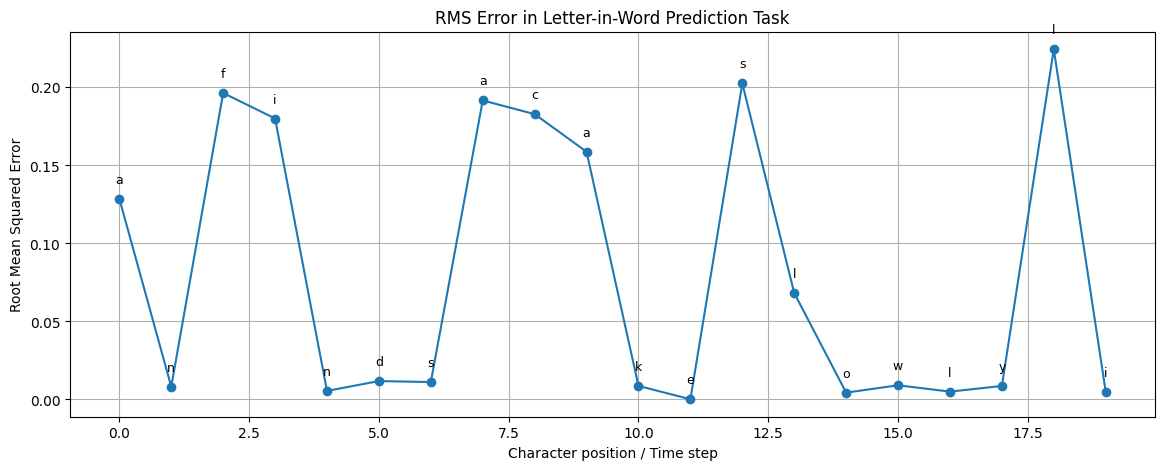

In [77]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():

    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    # model prediction
    logits = model(X)                         # [batch, seq_len, vocab_size]

    # convert logits to probabilities
    probs = torch.softmax(logits, dim=-1)     # [batch, seq_len, vocab_size]

    # convert true labels to one-hot vectors
    y_onehot = F.one_hot(
        y,
        num_classes=vocab_size
    ).float()                                 # [batch, seq_len, vocab_size]

    # RMS error over full output vector
    rms_error = torch.sqrt(
        torch.mean((probs - y_onehot) ** 2, dim=-1)
    )                                        # [batch, seq_len]

    # take first sample from batch
    errors = rms_error[0].cpu().numpy()
    labels = y[0].cpu().tolist()

# convert label indices back to characters
chars = [idx_to_char[i] for i in labels]

plt.figure(figsize=(14,5))

plt.plot(errors, marker='o')

for i, char in enumerate(chars):
    plt.text(
        i,
        errors[i] + 0.01,
        char,
        ha='center',
        fontsize=9
    )

plt.xlabel("Character position / Time step")
plt.ylabel("Root Mean Squared Error")
plt.title("RMS Error in Letter-in-Word Prediction Task")

plt.grid()
plt.show()